# Object + Classification

### Data Engineering

##### Data Preview

In [19]:
import os
data_root_path = "../../dataset_resplit_aug_1"
dir = os.listdir(data_root_path)
print(dir)

['data.yaml', 'test', 'train', 'valid']


In [ ]:
import os
import glob
from collections import Counter
import pandas as pd

data_root_path = "../../dataset_resplit_aug_1"
splits = ["train", "test", "valid"]

summary = {}

for split in splits:
    split_path = os.path.join(data_root_path, split)
    labels_path = os.path.join(split_path, "labels")

    if not os.path.isdir(labels_path):
        print(f"❌ {split}/labels folder not found")
        continue

    label_files = glob.glob(os.path.join(labels_path, "*.txt"))
    
    class_counter = Counter()

    for file in label_files:
        with open(file, "r") as f:
            lines = f.readlines()
            for line in lines:
                class_id = float(line.strip().split()[0])
                class_counter[class_id] += 1

    summary[split] = class_counter

    print(f"\n{split}:")
    for cls, count in sorted(class_counter.items()):
        print(f"Class {cls}: {count}")

# Optional: convert to DataFrame
df_summary = pd.DataFrame(summary).fillna(0).astype(int)
print("\nCombined Summary:")
print(df_summary)


##### New 2 States Model (DATASET)

In [83]:
import os
import glob
import torch
from torch.utils.data import Dataset
from PIL import Image

class YOLODetectionDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        self.images_dir = os.path.join(root_dir, split, "images")
        self.labels_dir = os.path.join(root_dir, split, "labels")

        self.image_paths = sorted(
            glob.glob(os.path.join(self.images_dir, "*.jpg"))
        )

        print(f"📂 Loaded {split} set")
        print(f"🖼️ Images: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = os.path.join(
            self.labels_dir,
            os.path.basename(img_path).replace(".jpg", ".txt")
        )

        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x_center, y_center, bw, bh = map(float, line.strip().split())

                    # Convert YOLO → Pascal VOC
                    x1 = (x_center - bw / 2) * w
                    y1 = (y_center - bh / 2) * h
                    x2 = (x_center + bw / 2) * w
                    y2 = (y_center + bh / 2) * h

                    boxes.append([float(x1), float(y1), float(x2), float(y2)])
                    labels.append(float(cls))

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(
                torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
            )

        return image, target


In [92]:
from torchvision import transforms

mean_ds, std_ds = torch.tensor([0.5775, 0.5520, 0.5217]), torch.tensor([0.2166, 0.2153, 0.2235])
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAdjustSharpness(2),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ds, std=std_ds)])

root = "../../dataset_resplit_aug_1"
train_dataset = YOLODetectionDataset(root, split="train", transform=transform)
valid_dataset = YOLODetectionDataset(root, split="valid", transform=transform)
test_dataset = YOLODetectionDataset(root, split="test", transform=transform)

print(f"✅ Train samples: {len(train_dataset)}")
print(f"✅ Valid samples: {len(valid_dataset)}")
print(f"✅ Test samples: {len(test_dataset)}")

print("\nSample from Train set:")
sample = train_dataset[0]
print(f"Image shape: {sample[0].shape}")
print(f"Target keys: {list(sample[1].keys())}")
print(f"Number of boxes: {len(sample[1]['boxes'])}")

📂 Loaded train set
🖼️ Images: 2756
📂 Loaded valid set
🖼️ Images: 394
📂 Loaded test set
🖼️ Images: 99
✅ Train samples: 2756
✅ Valid samples: 394
✅ Test samples: 99

Sample from Train set:
Image shape: torch.Size([3, 224, 224])
Target keys: ['boxes', 'labels']
Number of boxes: 1


In [93]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader

In [94]:
train_loader = DataLoader( train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader( valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader( test_dataset, batch_size=16, shuffle=False)

### Model selection

[เลือกโมเดลที่นี่](https://docs.pytorch.org/vision/main/models.html) แล้วเอาไปแก้ที่ Import

from torchvision.models แล้วไปแก้ที่บรรทัด 14-15



#### Model training

In [43]:
def calculate_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0 # ไม่ทับกันเลย
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - intersection_area
    return intersection_area / union_area

In [44]:
def manual_nms(boxes, scores, iou_threshold=0.3):
    idxs = scores.argsort(descending=True)
    keep = []

    while len(idxs) > 0:
        current = idxs[0]
        keep.append(current.item()) # เก็บกล่องที่มั่นใจที่สุดไว้

        if len(idxs) == 1: break
        remaining_idxs = idxs[1:]
        filtered_idxs = []
        for i in remaining_idxs:
            iou = calculate_iou(boxes[current], boxes[i])
            if iou < iou_threshold:
                filtered_idxs.append(i)
        idxs = torch.tensor(filtered_idxs)
    return torch.tensor(keep)

In [38]:
import torch
import torch.nn as nn

class MultiBoxLoss(nn.Module):
    def __init__(self, num_classes, grid_size=7):
        super(MultiBoxLoss, self).__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size
        self.mse_loss = nn.MSELoss(reduction='sum')
        self.ce_loss = nn.CrossEntropyLoss()
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='sum')

    def forward(self, predictions, target_boxes, target_labels):
        batch_size = predictions.size(0)
        device = predictions.device
        loc_l, obj_l, cls_l = torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)

        # วนลูปราย Batch
        for i in range(batch_size):
            pred = predictions[i] # [Anchors, Hg, Wg, 5 + C]
            gt_boxes = target_boxes[i]
            gt_labels = target_labels[i]

            # 1. Background (No Object) Loss
            # สร้าง target เป็น 0 ทั้งหมดสำหรับทุก Grid cells
            obj_target = torch.zeros(pred.shape[0], pred.shape[1], pred.shape[2], device=device)

            # 2. Positive Case (Match Ground Truth)
            for j, box in enumerate(gt_boxes):
                # คำนวณหาตำแหน่ง Grid (0.0 - 1.0 -> 0 - 6)
                gx, gy = box[0] * self.grid_size, box[1] * self.grid_size
                grid_i, grid_j = int(gx.clamp(0, self.grid_size-1)), int(gy.clamp(0, self.grid_size-1))

                # มาร์คตำแหน่งนี้ว่ามีวัตถุ (Target = 1)
                obj_target[0, grid_j, grid_i] = 1.0

                # ดึง Prediction เฉพาะจุดนั้นมาคำนวณ Loc และ Class
                target_pred = pred[0, grid_j, grid_i]
                loc_l += self.mse_loss(target_pred[:4], box)
                cls_l += self.ce_loss(target_pred[5:].unsqueeze(0), gt_labels[j].unsqueeze(0))

            # 3. Objectness Loss (คำนวณทีเดียวทั้ง Grid เพื่อความเร็ว)
            obj_l += self.bce_loss(pred[0, :, :, 4], obj_target[0])

        total_l = (loc_l + obj_l + cls_l) / batch_size
        return total_l, loc_l/batch_size, obj_l/batch_size, cls_l/batch_size

In [ ]:
def get_iou(box1, box2):
    """
    คำนวณ IoU ระหว่างกล่องสองใบ (Center Format: [cx, cy, w, h])
    """
    # แปลง Center [cx, cy, w, h] -> Corners [x1, y1, x2, y2]
    b1_x1, b1_y1 = box1[0] - box1[2]/2, box1[1] - box1[3]/2
    b1_x2, b1_y2 = box1[0] + box1[2]/2, box1[1] + box1[3]/2
    b2_x1, b2_y1 = box2[0] - box2[2]/2, box2[1] - box2[3]/2
    b2_x2, b2_y2 = box2[0] + box2[2]/2, box2[1] + box2[3]/2

    # หาพื้นที่ทับกัน (Intersection)
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    # คำนวณพื้นที่รวม (Union)
    b1_area = box1[2] * box1[3]
    b2_area = box2[2] * box2[3]
    union_area = b1_area + b2_area - inter_area

    return inter_area / (union_area + 1e-6)

def run_epoch(model, loader, optimizer, criterion, device, is_train=True):
    if is_train:
        model.train()
    else:
        model.eval()

    metrics = {
        'all': 0,
        'bboxes': 0,
        'classes': 0,
        'obj': 0,
        'cls_acc': 0,  # ความแม่นยำในการทายพันธุ์แมว
        'avg_iou': 0   # ความแม่นยำในการวาดกล่อง (0.0 - 1.0)
    }

    total_samples = 0
    grid_size = 7 # ปรับให้ตรงกับโมเดล (DenseNet/ResNet มักเป็น 7x7 สำหรับภาพ 224)

    with torch.set_grad_enabled(is_train):
        for images, labels, boxes in loader:
            images = images.to(device)
            # labels และ boxes เป็น List ของ Tensor เนื่องจากแต่ละภาพมีจำนวนวัตถุไม่เท่ากัน
            labels = [l.to(device) for l in labels]
            boxes = [b.to(device) for b in boxes]

            if is_train:
                optimizer.zero_grad()

            # Forward Pass
            cls_out, det_out = model(images)

            # Loss Calculation
            loss_all, loss_loc, loss_obj, loss_cls = criterion(det_out, boxes, labels)

            if is_train:
                loss_all.backward()
                optimizer.step()

            # --- Metrics Calculation ---
            with torch.no_grad():
                batch_cls_corr = 0
                batch_iou_sum = 0
                total_objects_in_batch = 0

                for i in range(len(labels)):
                    gt_labels = labels[i]
                    gt_boxes = boxes[i]

                    for j in range(len(gt_labels)):
                        # หาตำแหน่ง Grid ที่วัตถุนั้นอยู่
                        gx = int(gt_boxes[j][0] * grid_size)
                        gy = int(gt_boxes[j][1] * grid_size)
                        gx, gy = max(0, min(gx, grid_size-1)), max(0, min(gy, grid_size-1))

                        # 1. วัดค่า IoU (ความแม่นยำของตำแหน่งกล่อง)
                        pred_box = det_out[i, 0, gy, gx, :4]
                        current_iou = get_iou(pred_box, gt_boxes[j])
                        batch_iou_sum += current_iou.item()

                        # 2. วัดค่า Class Accuracy (ทายพันธุ์ถูกไหม)
                        pred_class_logits = det_out[i, 0, gy, gx, 5:]
                        if torch.argmax(pred_class_logits) == gt_labels[j]:
                            batch_cls_corr += 1

                        total_objects_in_batch += 1

                # เก็บค่าเฉลี่ยราย Batch
                if total_objects_in_batch > 0:
                    metrics['cls_acc'] += (batch_cls_corr / total_objects_in_batch)
                    metrics['avg_iou'] += (batch_iou_sum / total_objects_in_batch)

                metrics['all'] += loss_all.item()
                metrics['bboxes'] += loss_loc.item()
                metrics['obj'] += loss_obj.item()
                metrics['classes'] += loss_cls.item()
                total_samples += 1

    # หารด้วยจำนวน batch เพื่อหาค่าเฉลี่ยต่อ Epoch
    for key in metrics:
        metrics[key] /= len(loader)

    return metrics

In [78]:
import torch
import torch.nn as nn

class YOLODetector(nn.Module):
    def __init__(self, num_classes=6, grid_size=7):
        super().__init__()

        self.S = grid_size
        self.C = num_classes

        # -------------------------
        # Backbone CNN
        # -------------------------
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 28

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 14

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool2d((self.S, self.S))

        # Detection Head
        self.head = nn.Conv2d(512, 5 + self.C, kernel_size=1)

    def forward(self, x):

        x = self.backbone(x)
        x = self.pool(x)
        x = self.head(x)

        # [B, 5+C, S, S] → [B, S, S, 5+C]
        x = x.permute(0, 2, 3, 1)

        # Apply activations
        x[..., 0:2] = torch.sigmoid(x[..., 0:2])   # cx, cy
        x[..., 2:4] = torch.sigmoid(x[..., 2:4])   # w, h
        # objectness raw (use BCEWithLogits)
        # class logits raw (use CrossEntropy)

        return x


In [71]:
def box_iou(box1, box2):
    """
    box1: [4]
    box2: [4]
    format: [cx, cy, w, h]
    """

    # Convert to corner format
    b1_x1 = box1[0] - box1[2] / 2
    b1_y1 = box1[1] - box1[3] / 2
    b1_x2 = box1[0] + box1[2] / 2
    b1_y2 = box1[1] + box1[3] / 2

    b2_x1 = box2[0] - box2[2] / 2
    b2_y1 = box2[1] - box2[3] / 2
    b2_x2 = box2[0] + box2[2] / 2
    b2_y2 = box2[1] + box2[3] / 2

    # Intersection
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)

    inter_area = inter_w * inter_h

    # Union
    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]

    union = area1 + area2 - inter_area

    return inter_area / (union + 1e-6)


In [72]:
def build_target(targets, S, C, device):

    B = targets["boxes"].size(0)

    target_tensor = torch.zeros((B, S, S, 5 + C), device=device)

    for b in range(B):

        boxes = targets["boxes"][b]      # [N,4]
        labels = targets["labels"][b]    # [N]

        for i in range(len(boxes)):

            box = boxes[i]
            label = labels[i]

            cx, cy, w, h = box

            grid_x = int(cx * S)
            grid_y = int(cy * S)

            grid_x = min(S-1, max(0, grid_x))
            grid_y = min(S-1, max(0, grid_y))

            target_tensor[b, grid_y, grid_x, 0:4] = box
            target_tensor[b, grid_y, grid_x, 4] = 1.0
            target_tensor[b, grid_y, grid_x, 5 + label] = 1.0

    return target_tensor


In [74]:
class YOLOLoss(torch.nn.Module):
    def __init__(self, S=7, C=6):
        super().__init__()
        self.S = S
        self.C = C

        self.mse = torch.nn.MSELoss()
        self.bce = torch.nn.BCEWithLogitsLoss()
        self.ce = torch.nn.CrossEntropyLoss()

    def forward(self, preds, targets):

        obj_mask = targets[..., 4] == 1
        noobj_mask = targets[..., 4] == 0

        # Localization loss (only where object exists)
        loc_loss = self.mse(
            preds[..., 0:4][obj_mask],
            targets[..., 0:4][obj_mask]
        )

        # Objectness loss
        obj_loss = self.bce(
            preds[..., 4][obj_mask],
            targets[..., 4][obj_mask]
        )

        noobj_loss = self.bce(
            preds[..., 4][noobj_mask],
            targets[..., 4][noobj_mask]
        )

        # Class loss
        if obj_mask.sum() > 0:
            class_loss = self.ce(
                preds[..., 5:][obj_mask],
                torch.argmax(targets[..., 5:][obj_mask], dim=1)
            )
        else:
            class_loss = torch.tensor(0., device=preds.device)

        total_loss = loc_loss + obj_loss + 0.5 * noobj_loss + class_loss

        return total_loss, loc_loss, obj_loss, class_loss


In [75]:
def train_epoch(model, loader, optimizer, criterion, device, S=7, C=6):

    model.train()

    total_loss = 0
    total_iou = 0
    total_correct = 0
    total_objects = 0

    for images, targets in loader:

        images = images.to(device)
        targets["boxes"] = targets["boxes"].to(device)
        targets["labels"] = targets["labels"].to(device)

        # Build YOLO grid target
        target_grid = build_target(targets, S, C, device)

        optimizer.zero_grad()

        preds = model(images)

        loss, loc_l, obj_l, cls_l = criterion(preds, target_grid)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

        # ------------------------
        # Metrics (IoU + Accuracy)
        # ------------------------
        with torch.no_grad():

            obj_mask = target_grid[..., 4] == 1

            if obj_mask.sum() > 0:

                pred_boxes = preds[..., 0:4][obj_mask]
                gt_boxes = target_grid[..., 0:4][obj_mask]

                # IoU
                for pb, gb in zip(pred_boxes, gt_boxes):
                    total_iou += box_iou(pb, gb).item()

                # Class accuracy
                pred_cls = torch.argmax(preds[..., 5:][obj_mask], dim=1)
                gt_cls = torch.argmax(target_grid[..., 5:][obj_mask], dim=1)

                total_correct += (pred_cls == gt_cls).sum().item()
                total_objects += obj_mask.sum().item()

    avg_loss = total_loss / len(loader)
    avg_iou = total_iou / max(total_objects, 1)
    acc = total_correct / max(total_objects, 1)

    return {
        "loss": avg_loss,
        "iou": avg_iou,
        "acc": acc
    }


In [76]:
def valid_epoch(model, loader, criterion, device, S=7, C=6):

    model.eval()

    total_loss = 0

    with torch.no_grad():
        for images, targets in loader:

            images = images.to(device)
            targets["boxes"] = targets["boxes"].to(device)
            targets["labels"] = targets["labels"].to(device)

            target_grid = build_target(targets, S, C, device)
            preds = model(images)

            loss, _, _, _ = criterion(preds, target_grid)

            total_loss += loss.item()

    return total_loss / len(loader)


In [98]:
# ===============================
# Setup
# ===============================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 6
grid_size = 7
num_epochs = 20

model = YOLODetector(
    num_classes=num_classes,
    grid_size=grid_size
).to(device)

criterion = YOLOLoss(
    S=grid_size,
    C=num_classes
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)


In [97]:
for epoch in range(num_epochs):

    train_res = train_epoch(
        model, train_loader,
        optimizer, criterion,
        device
    )

    val_loss = valid_epoch(
        model, valid_loader,
        criterion,
        device
    )

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_res['loss']:.3f}")
    print(f"IoU: {train_res['iou']:.3f}")
    print(f"Class Acc: {train_res['acc']*100:.2f}%")
    print(f"Valid Loss: {val_loss:.3f}")
    print("-" * 30)


TypeError: MultiBoxLoss.forward() missing 1 required positional argument: 'target_labels'

In [ ]:
model = SimpleYOLO(num_classes=3)
x = torch.randn(2, 3, 640, 640)

y = model(x)
print(y.shape)


torch.Size([2, 1, 7, 7, 8])


In [69]:
# Setup
import torch

num_classes = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleYOLO(num_classes=num_classes).to(device)
criterion = MultiBoxLoss(num_classes=num_classes)
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=5e-5,
    momentum=0.9,
    weight_decay=5e-4
)

for epoch in range(3):
    train_res = run_epoch(model, train_loader, optimizer, criterion, device, is_train=True)
    valid_res = run_epoch(model, valid_loader, optimizer, criterion, device, is_train=False)

    print(f"Epoch {epoch+16}")
    print(f"TRAIN | Loss: {train_res['all']:.3f} [Box: {train_res['bboxes']:.3f}, Cls: {train_res['classes']:.3f}] | Acc: {train_res['cls_acc']*100:.2f}%")
    print(f"VALID | Loss: {valid_res['all']:.3f} [Box: {valid_res['bboxes']:.3f}, Cls: {valid_res['classes']:.3f}] | Acc: {valid_res['cls_acc']*100:.2f}%")
    print("-" * 30)

IndexError: invalid index of a 0-dim tensor. Use `tensor.item()` in Python or `tensor.item<T>()` in C++ to convert a 0-dim tensor to a number

In [ ]:
torch.save(model.state_dict(), "DenseNet121_Cat.pth")

In [ ]:
from google.colab import files

files.download('/content/DenseNet121_Cat.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Model Testing/Validation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset.le.classes_)
model = PretrainedCatDetector(num_classes=num_classes)
pretrained_model = "DenseNet121_Cat.pth"
model.load_state_dict(torch.load(pretrained_model, map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
test_res = run_epoch(model, test_loader, None, criterion, device, is_train=False)

print("📊 FINAL TEST RESULTS")
print(f"Total Loss: {test_res['all']:.4f}")
print(f"Bbox Precision (MSE): {test_res['bboxes']:.4f}")
print(f"Classification Accuracy: {test_res['cls_acc']*100:.2f}%")

📊 FINAL TEST RESULTS
Total Loss: 4.6973
Bbox Precision (MSE): 0.3171
Classification Accuracy: 77.53%


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.ops import nms

def predict_custom_image(model, image_path, class_names, device, threshold=0.1):
    predict_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5121, 0.4615, 0.4059], std=[0.2247, 0.2278, 0.2331])
    ])
    img_raw = Image.open(image_path).convert("RGB")
    img_tensor = predict_transform(img_raw).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        _, det_out = model(img_tensor)
    pred = det_out[0, 0]
    obj_probs = torch.sigmoid(pred[..., 4])
    mask = obj_probs > threshold
    if not mask.any():
        print(f"⚠️ ไม่พบวัตถุที่มีความมั่นใจเกิน {threshold*100}%")
        plt.imshow(img_raw.resize((224, 224)))
        plt.axis('off')
        plt.show()
        return

    valid_preds = pred[mask]
    valid_obj_probs = obj_probs[mask]
    boxes = []
    for p in valid_preds:
        cx, cy, bw, bh = p[:4]
        x1 = (cx - bw/2) * 224
        y1 = (cy - bh/2) * 224
        x2 = (cx + bw/2) * 224
        y2 = (cy + bh/2) * 224
        boxes.append(torch.stack([x1, y1, x2, y2]))
    boxes = torch.stack(boxes).to(device)
    valid_obj_probs = valid_obj_probs.to(device)
    keep = nms(boxes, valid_obj_probs, iou_threshold=0.3)
    boxes = boxes.cpu()
    valid_obj_probs = valid_obj_probs.cpu()
    valid_preds = valid_preds.cpu()
    keep = keep.cpu()

    plt.figure(figsize=(8, 8))
    plt.imshow(img_raw.resize((224, 224)))
    ax = plt.gca()

    for idx in keep:
        b = boxes[idx].numpy()
        p = valid_preds[idx]
        conf = valid_obj_probs[idx].item()
        cls_id = torch.argmax(p[5:]).item()
        rect = plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                             fill=False, color='lime', linewidth=3)
        ax.add_patch(rect)
        label_text = f"{class_names[cls_id]} {conf:.2f}"
        ax.text(b[0], b[1]-5, label_text, color='white', weight='bold',
                bbox=dict(facecolor='lime', alpha=0.6, edgecolor='none'))

    plt.axis('off')
    plt.title(f"Prediction for: {image_path.split('/')[-1]}")
    plt.show()

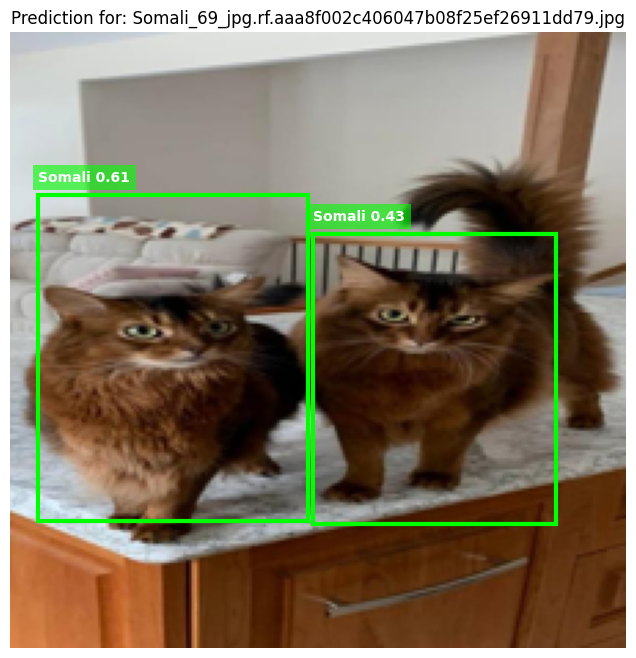

In [ ]:
class_names = train_dataset.le.classes_
images_path = "/content/Cat-5/train/Somali_69_jpg.rf.aaa8f002c406047b08f25ef26911dd79.jpg"
predict_custom_image(model, images_path, class_names, device)

# Object Only

In [ ]:
%%capture
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="MGwAmKATBJUw8Gbdl9YQ")
project = rf.workspace("summer-2nyu3").project("708")
version = project.version(1)
dataset = version.download("multiclass")

loading Roboflow workspace...
loading Roboflow project...
Exporting format multiclass in progress : 85.0%
Version export complete for multiclass format



Extracting Dataset Version Zip to 708-1 in multiclass:: 100%|██████████| 1506/1506 [00:00<00:00, 2275.39it/s]


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="MGwAmKATBJUw8Gbdl9YQ")
project = rf.workspace("youssef").project("cat-bg5f4")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cat-1 in yolov8:: 100%|██████████| 8234/8234 [00:02<00:00, 3329.59it/s]
